# Problem 1: Perspective Transform for UAV Bird-eye View

## Objective

In this practice, we apply perspective transformation to convert an oblique UAV image into an approximate bird-eye view.

This task is related to geometric transformations, image warping, inverse mapping, resampling, and interpolation.

## Main idea

A UAV image captured from an oblique angle contains perspective distortion. If the selected ground region is approximately planar, we can select four corner points on the original image and map them to a rectangular output plane.

The transformation is computed using a homography matrix.

## Pipeline

1. Load the UAV image.
2. Read four selected source points from a JSON file.
3. Define four destination points as a rectangle.
4. Compute the perspective transform matrix.
5. Warp the image to obtain a bird-eye view.
6. Compare different interpolation methods.

## Using L09_Pro1_point_selection.py
```bash
cd main/L09_geometric_transformations_*
python L09_Pro1_point_selection.py --image dataset/pro1_01.jpg --output metadata/setpoints_01.json
```

```note
Left click: chọn điểm
Right click: xoá điểm cuối
r: reset toàn bộ điểm
s: lưu tọa độ ra file JSON
q hoặc ESC: thoát
```

## Limitation

Perspective transform works well when the selected region is approximately planar. It cannot correctly fix 3D objects such as cars, trees, poles, or buildings because these objects do not lie on the same ground plane.

### 📦 Bước 1: Khai báo và Nhập các thư viện cần thiết (Import Libraries)

Trước khi tiến hành xử lý ảnh, chúng ta cần nạp các công cụ và thư viện hỗ trợ:
- **`cv2` (OpenCV):** Thư viện thị giác máy tính cốt lõi, dùng để đọc ảnh, vẽ hình học, tính toán ma trận Homography và thực hiện phép biến đổi phối cảnh (*Warp Perspective*).
- **`numpy` (`np`):** Hỗ trợ tính toán ma trận, mảng nhiều chiều và xử lý tọa độ điểm số thực (`np.float32`).
- **`matplotlib.pyplot` (`plt`):** Dùng để trực quan hóa, hiển thị ảnh gốc và ảnh kết quả trực tiếp bên trong Notebook.
- **`json` & `Path`:** Quản lý đường dẫn file và đọc/ghi dữ liệu tọa độ 4 điểm góc từ file cấu hình `.json`.

In [8]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### 📂 Bước 2: Thiết lập đường dẫn dữ liệu (Define File Paths)

Định nghĩa đường dẫn đến các file dữ liệu đầu vào:
- **`image_path`:** Đường dẫn đến ảnh UAV chụp nghiêng góc (*Oblique UAV Image*).
- **`points_path`:** Đường dẫn đến file chứa tọa độ 4 điểm nguồn (*Source Points*) đã được chọn trước đó từ công cụ tương tác (`L09_Pro1_point_selection.py`).

In [36]:
image_path = Path("dataset/pro1_01.jpg")
points_path = Path("metadata/setpoints_02.json")

### 🖼️ Bước 3: Đọc và Trực quan hóa ảnh UAV gốc (Load & Visualize Image)

Các thao tác thực hiện trong cell này:
1. **Đọc ảnh:** Sử dụng `cv2.imread()` để tải ảnh từ ổ cứng. Kiểm tra lỗi nếu file không tồn tại.
2. **Chuyển đổi hệ màu:** Mặc định OpenCV đọc ảnh theo thứ tự màu **BGR** (*Blue-Green-Red*). Để hiển thị đúng màu sắc trên `matplotlib` (yêu cầu hệ màu **RGB**), ta dùng hàm `cv2.cvtColor()`.
3. **Hiển thị thông tin & hình ảnh:** In ra kích thước ảnh (`Height`, `Width`, `Channels`) và hiển thị ảnh gốc lên màn hình.

Image shape: (3018, 4606, 3)
Width: 4606
Height: 3018


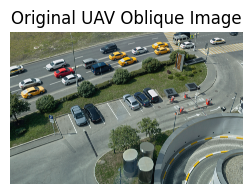

In [37]:
image_bgr = cv2.imread(str(image_path))

if image_bgr is None:
    raise ValueError(f"Cannot read image from: {image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

height, width = image_rgb.shape[:2]

print("Image shape:", image_rgb.shape)
print("Width:", width)
print("Height:", height)

plt.figure(figsize=(3, 3))
plt.imshow(image_rgb)
plt.title("Original UAV Oblique Image")
plt.axis("off")
plt.show()

### 📐 Bước 4: Đọc tọa độ điểm nguồn & Tính toán kích thước ảnh đích (Load Points & Compute Output Size)

Cell này thực hiện các bước chuẩn bị hình học quan trọng:
1. **Đọc tọa độ từ JSON:** Tải danh sách 4 điểm nguồn ($P_1, P_2, P_3, P_4$) đã lưu trong file `Pro1_selected_points.json` và chuyển thành mảng `np.float32`.
2. **Tính kích thước ảnh đầu ra tự động (`output_width`, `output_height`):**
   - Thay vì chọn kích thước tùy ý, ta dùng chuẩn đo khoảng cách Euclid (`np.linalg.norm`) để tính chiều dài 4 cạnh của tứ giác nguồn: `top_width`, `bottom_width`, `left_height`, `right_height`.
   - Chiều rộng ảnh đích được lấy theo giá trị lớn hơn giữa cạnh trên và cạnh dưới: $\max(\text{top\_width}, \text{bottom\_width})$.
   - Chiều cao ảnh đích được lấy theo giá trị lớn hơn giữa cạnh trái và cạnh phải: $\max(\text{left\_height}, \text{right\_height})$.

💡 *Cách làm này giúp ảnh kết quả sau khi nắn chỉnh giữ được tỷ lệ thực tế và độ phân giải tốt nhất, không bị co kéo hay mất chi tiết.*

In [38]:
if not points_path.exists():
    raise FileNotFoundError(
        f"Cannot find {points_path}. "
        "Run select_perspective_points.py first to select and save 4 points."
    )

with open(points_path, "r", encoding="utf-8") as f:
    points_data = json.load(f)

src_points = np.float32([
    [p["x"], p["y"]] for p in points_data["points"]
])

print("Point order:", points_data["order"])
print("Source points:")
print(src_points)

# =============================================================
"""
Tính kích thước output tự động
Thay vì tự nhập width/height cố định, ta tính dựa trên khoảng cách giữa các cạnh của tứ giác đã chọn.
"""
def distance(p1, p2):
    return np.linalg.norm(p1 - p2)

top_width = distance(src_points[0], src_points[1])
bottom_width = distance(src_points[3], src_points[2])
left_height = distance(src_points[0], src_points[3])
right_height = distance(src_points[1], src_points[2])

output_width = int(max(top_width, bottom_width))
output_height = int(max(left_height, right_height))

print("\nTop width:", top_width)
print("Bottom width:", bottom_width)
print("Left height:", left_height)
print("Right height:", right_height)

print("Output width:", output_width)
print("Output height:", output_height)

Point order: ['top-left', 'top-right', 'bottom-right', 'bottom-left']
Source points:
[[ 803. 1520.]
 [2727.  938.]
 [3336. 1849.]
 [1132. 2612.]]

Top width: 2010.0995
Bottom width: 2332.3347
Left height: 1140.4845
Right height: 1095.8112
Output width: 2332
Output height: 1140


### 🎯 Bước 5: Trực quan hóa vùng mặt phẳng đã chọn trên ảnh gốc (Visualize Selected Region)

Để kiểm chứng xem 4 điểm nguồn đã bao trùm đúng vùng mặt phẳng hay chưa, ta vẽ các ký hiệu trực quan lên một bản sao của ảnh gốc (`vis`):
- **`cv2.circle()`:** Vẽ các chấm tròn màu đỏ tại vị trí 4 góc.
- **`cv2.putText()`:** Đánh số thứ tự từ $1 \rightarrow 4$ tại mỗi góc để dễ theo dõi quy tắc thứ tự điểm.
- **`cv2.polylines()`:** Nối 4 điểm thành một đường viền đa giác khép kín (`isClosed=True`).

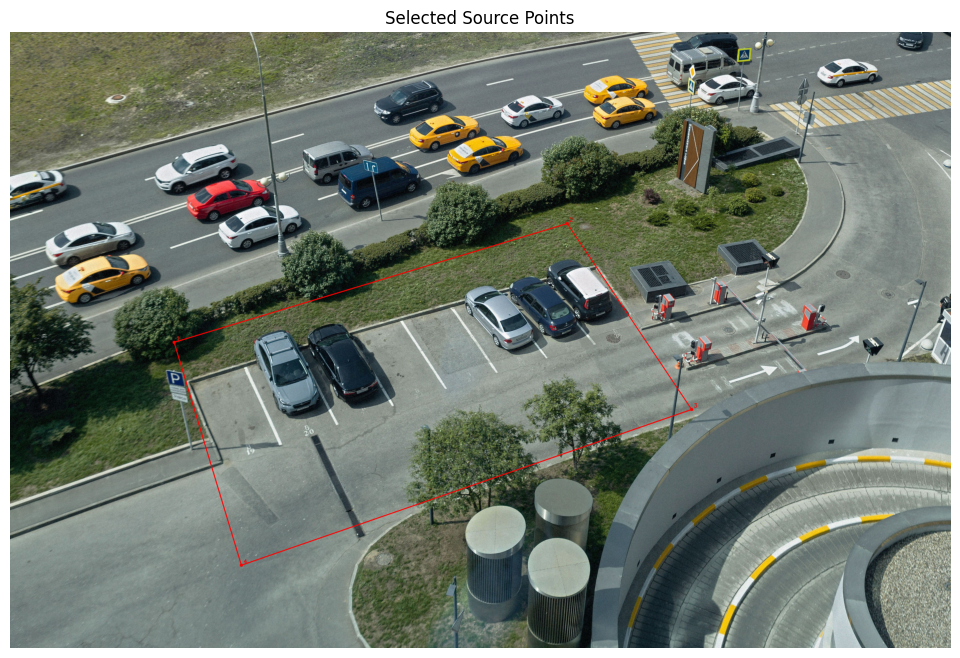

In [39]:
vis = image_rgb.copy()

for i, (x, y) in enumerate(src_points):
    x, y = int(x), int(y)
    
    cv2.circle(vis, (x, y), 8, (255, 0, 0), -1)
    cv2.putText(
        vis,
        str(i + 1),
        (x + 10, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 0, 0),
        2
    )

polygon = src_points.astype(np.int32)
cv2.polylines(
    vis,
    [polygon],
    isClosed=True,
    color=(255, 0, 0),
    thickness=3
)

plt.figure(figsize=(14, 8))
plt.imshow(vis)
plt.title("Selected Source Points")
plt.axis("off")
plt.show()

### 📍 Bước 6: Định nghĩa tọa độ 4 điểm đích (Define Destination Points)

Để biến vùng hình thang trên ảnh nghiêng thành một hình chữ nhật chuẩn góc nhìn từ trên xuống (*Top-down / Bird-eye view*), ta ánh xạ 4 điểm nguồn tương ứng vào 4 góc của khung ảnh mới kích thước `output_width` $\times$ `output_height`:
- Điểm 1 (`Top-Left`): $(0, 0)$
- Điểm 2 (`Top-Right`): $(\text{width}-1, 0)$
- Điểm 3 (`Bottom-Right`): $(\text{width}-1, \text{height}-1)$
- Điểm 4 (`Bottom-Left`): $(0, \text{height}-1)$

⚠️ *Lưu ý:* Thứ tự của `dst_points` **bắt buộc phải khớp hoàn toàn** với thứ tự của `src_points`.

In [40]:
dst_points = np.float32([
    [0, 0],                              # top-left
    [output_width - 1, 0],               # top-right
    [output_width - 1, output_height - 1],# bottom-right
    [0, output_height - 1]               # bottom-left
])

print("Destination points:")
print(dst_points)

Destination points:
[[   0.    0.]
 [2331.    0.]
 [2331. 1139.]
 [   0. 1139.]]


### 🚀 Bước 7: Tính Ma trận Homography & Thực hiện biến đổi phối cảnh (Warp Perspective)

Đây là bước cốt lõi của thuật toán Geometric Transformations:
1. **Tính ma trận biến đổi $H$ (`cv2.getPerspectiveTransform`):** Giải hệ phương trình để tìm ma trận Homography kích thước $3 \times 3$ ánh xạ chính xác `src_points` sang `dst_points`.
2. **Nắn chỉnh ảnh (`cv2.warpPerspective`):** Áp dụng ma trận $H$ lên toàn bộ ảnh gốc. Quá trình này thực hiện **Inverse Warping** (lấy tọa độ đích nhân với $H^{-1}$ để tìm pixel nguồn tương ứng) kết hợp phương pháp nội suy song tuyến tính (`INTER_LINEAR`) để tính giá trị màu cho từng pixel, giúp tránh tạo ra các lỗ rỗng trên ảnh kết quả.

Homography matrix:
[[ 1.36820109e+00 -4.12214431e-01 -4.72099541e+02]
 [ 4.49414458e-01  1.48569316e+00 -2.61913341e+03]
 [ 1.43116208e-05  2.05972308e-04  1.00000000e+00]]


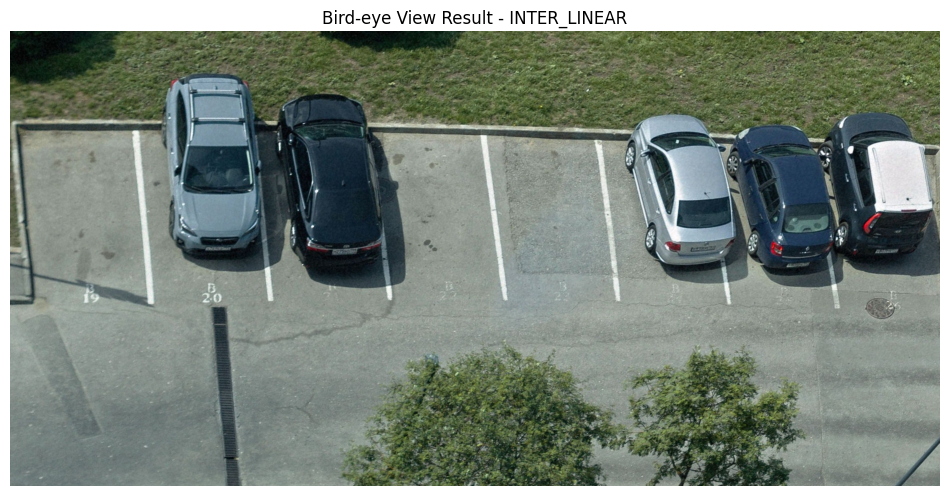

In [41]:
H = cv2.getPerspectiveTransform(src_points, dst_points)

warped_bgr = cv2.warpPerspective(
    image_bgr,
    H,
    (output_width, output_height),
    flags=cv2.INTER_LINEAR
)

warped_rgb = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB)

print("Homography matrix:")
print(H)

plt.figure(figsize=(12, 8))
plt.imshow(warped_rgb)
plt.title("Bird-eye View Result - INTER_LINEAR")
plt.axis("off")
plt.show()

### ⚖️ Bước 8: So sánh đối chứng trước và sau nắn chỉnh (Side-by-Side Comparison)

Đặt ảnh gốc (kèm viền đỏ vùng lựa chọn) và ảnh kết quả (*Bird-eye View*) cạnh nhau trên cùng một khung hình (`plt.subplot`) để đánh giá trực quan hiệu quả của phép biến đổi phối cảnh.

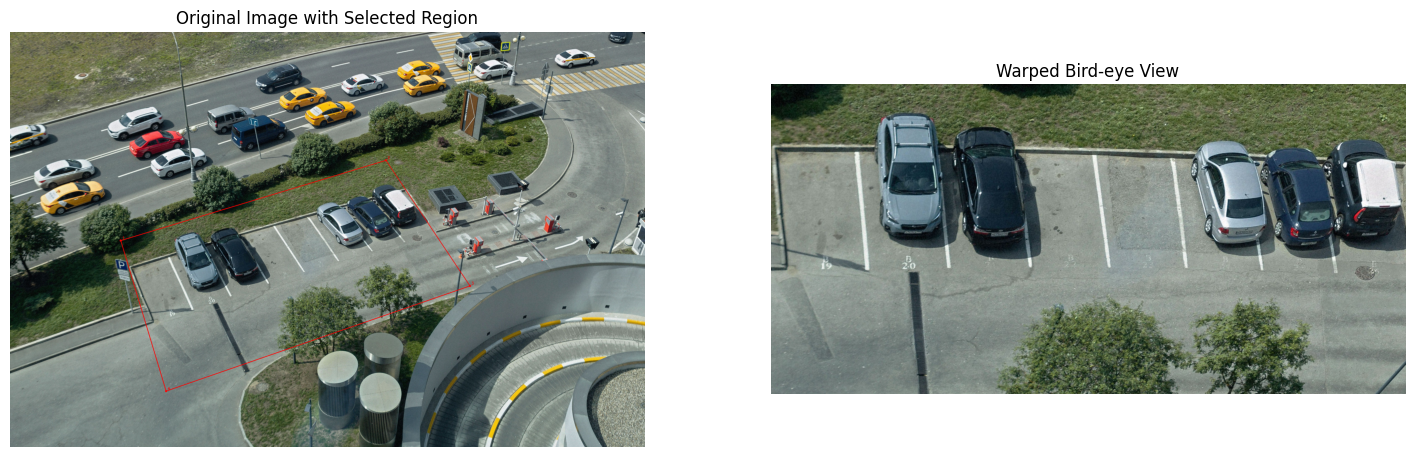

In [42]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
plt.imshow(vis)
plt.title("Original Image with Selected Region")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(warped_rgb)
plt.title("Warped Bird-eye View")
plt.axis("off")

plt.show()

### 🔍 Bước 9: Thử nghiệm & So sánh các phương pháp Nội suy (Resampling / Interpolation Methods)

Khi thực hiện warping, lưới pixel mới thường rơi vào các tọa độ số thực không trùng khớp với pixel nguyên của ảnh gốc. Cell này so sánh 4 thuật toán nội suy phổ biến nhất trong OpenCV:
- **`INTER_NEAREST` (Lân cận gần nhất):** Lấy giá trị của pixel gần nhất. Tốc độ rất nhanh nhưng ảnh bị hiện tượng răng cưa và vỡ hạt (*blocky/jagged artifacts*).
- **`INTER_LINEAR` (Song tuyến tính):** Tính trung bình có trọng số của 4 pixel xung quanh. Cho cân bằng tốt giữa tốc độ và độ mịn.
- **`INTER_CUBIC` (Bicubic):** Nội suy dựa trên 16 pixel xung quanh. Giúp đường nét mượt mà hơn nhưng tính toán lâu hơn.
- **`INTER_LANCZOS4`:** Sử dụng hàm Lanczos trên 8x8 pixel. Giữ chi tiết sắc nét nhất nhưng có thể tạo viền rực (*ringing artifacts*).

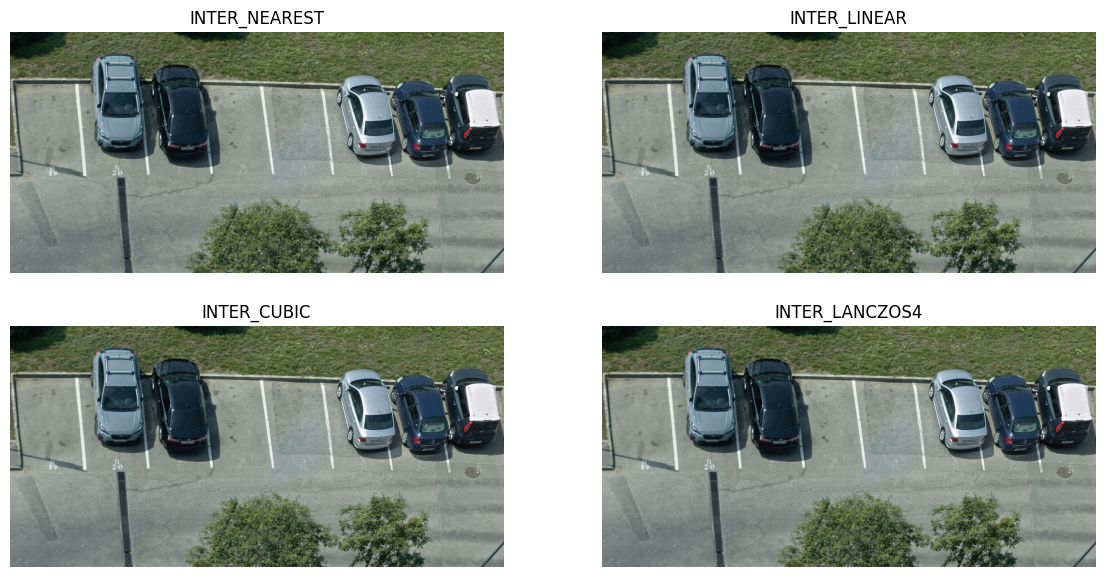

In [50]:
interpolation_methods = {
    "INTER_NEAREST": cv2.INTER_NEAREST,
    "INTER_LINEAR": cv2.INTER_LINEAR,
    "INTER_CUBIC": cv2.INTER_CUBIC,
    "INTER_LANCZOS4": cv2.INTER_LANCZOS4
}

warped_results = {}

for name, method in interpolation_methods.items():
    warped = cv2.warpPerspective(
        image_bgr,
        H,
        (output_width, output_height),
        flags=method
    )
    
    warped_results[name] = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 7))

for i, (name, result) in enumerate(warped_results.items()):
    plt.subplot(2, 2, i + 1)
    plt.imshow(result)
    plt.title(name)
    plt.axis("off")

plt.show()

## Observation Problem 1:

After applying perspective transformation, the selected ground region is warped into an approximate bird-eye view.

However, the result is not a true orthophoto because:

1. The transform assumes the selected region is planar.
2. Cars, trees, poles, and other 3D objects do not lie on the ground plane.
3. Lens distortion is not corrected.
4. Camera pose and real-world scale are not used.
5. Topographic relief is not considered.

## Interpolation comparison

- `INTER_NEAREST`: fastest but may produce jagged/blocky artifacts.
- `INTER_LINEAR`: balanced and commonly used.
- `INTER_CUBIC`: smoother but may introduce blur.
- `INTER_LANCZOS4`: sharper in some cases but may create ringing artifacts.

## UAV-CV connection

This practice is related to UAV mapping and orthophoto generation. Perspective transform can be used as a simplified rectification step when the ground is approximately planar, but real orthophoto or orthomosaic generation requires additional data such as camera calibration, camera pose, GPS/IMU information, and DEM/DSM.